# House Price Prediction


## Setup


In [48]:
# Common imports
import numpy as np
import os
import sklearn

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
PRJ_NAME = "house_price_prediction"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", PRJ_NAME)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Get the Data


#### Download the Data

In [49]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"


def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path, filter="data")
    housing_tgz.close()

In [50]:
fetch_housing_data()

#### Load data using Pandas


In [51]:
import pandas as pd


def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

#### Take a Quick Look at the Data Structure


In [52]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [53]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


- All attributes are numerical except ocean_proximity.
  It is stored as an object but contains text values, and the repeated entries show that it is a categorical attribute.

- The total_bed
  rooms attribute has only 20,433 non-null values, meaning that 207 districts are miss
  ing this feature


In [54]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [55]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Saving figure attribute_histogram_plots


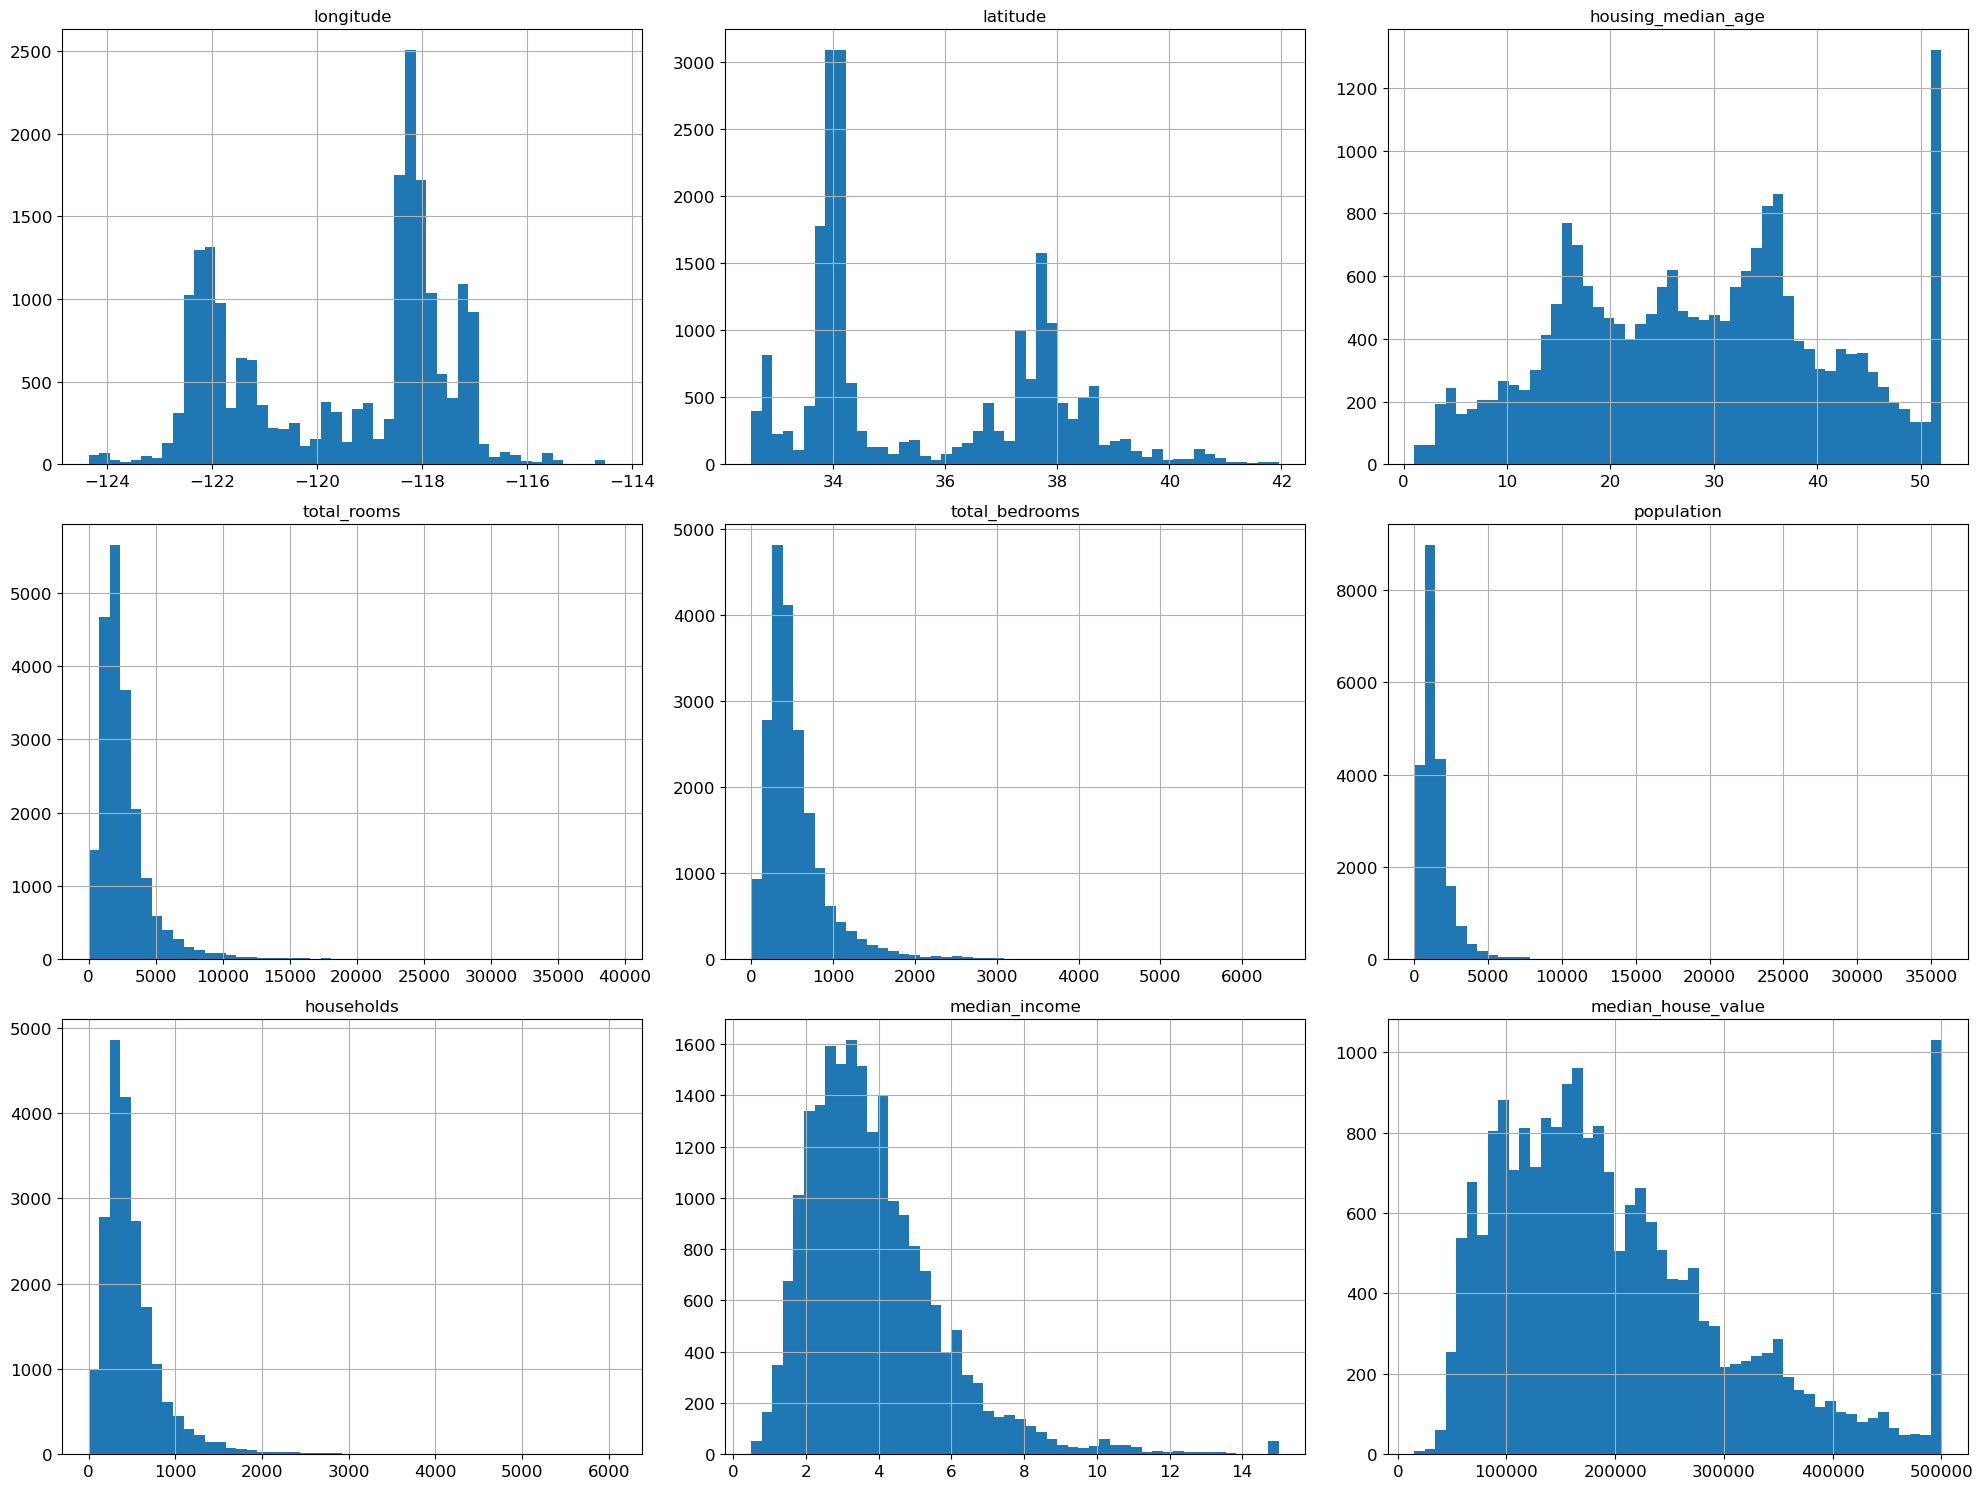

In [56]:

%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()


**Few things to note**

1. _Sharp cutoffs / pile-ups at exact values_

- Histograms show a tall spike of values exactly at the right-hand edge for median_income (~15), housing_median_age (around the max age), and median_house_value (a large spike at $500,000).

- Real-world measurements rarely produce such an exact, abrupt boundary — that usually means values beyond a threshold were clipped (capped).

2. _Range inconsistent with expected units_

- median_income values sit roughly between 0.5 and 15. That is far too small for USD, so the values were scaled (e.g., each unit ≈ $10,000).

3. _Missing tail beyond the cap_

- For the house value histogram there are no values beyond $500k (the distribution abruptly stops), which suggests a hard upper limit was applied to that label.

4. _Many histograms are tail heavy:_

- They extend much farther to the right of
  the median than to the left. This may make it a bit harder for some Machine
  Learning algorithms to detect patterns.


#### Create a Test Set


In [57]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [58]:
len(train_set)

16512

In [59]:
len(test_set)

4128

**Creating Income Categories for Stratified Sampling**

Median income is a key feature for predicting median housing prices (_given_). To ensure that the test set is representative of all income levels, we create an income category attribute and use it for stratified sampling.

Since median_income is a continuous numerical variable, we discretize it into a small number of meaningful categories (strata). This avoids bias while ensuring each stratum has enough samples.

_Based on the income distribution:_

- Most values lie between 1.5 and 6 (i.e., $15,000– $60,000)
- A few values go beyond 6
- We limit the number of categories so each stratum is sufficiently large

_We create 5 income categories:_

- Category 1: 0 to 1.5
- Category 2: 1.5 to 3.0
- Category 3: 3.0 to 4.5
- Category 4: 4.5 to 6.0
- Category 5: 6.0 and above


<Axes: xlabel='income_cat'>

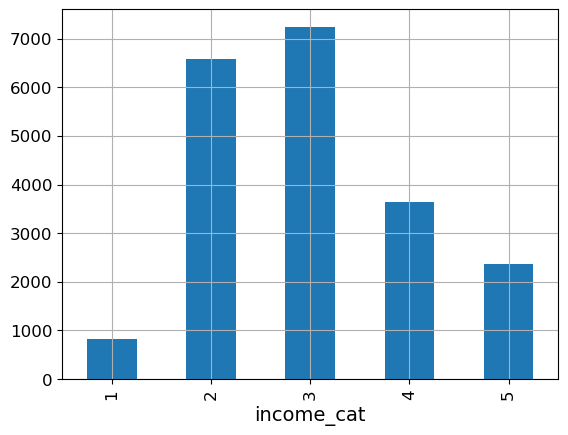

In [60]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

housing["income_cat"].value_counts().sort_index().plot(kind="bar", grid=True)
# Add .sort_index() to make the bars in order 1 → 5

In [61]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [62]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)


train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame(
    {
        "Overall": income_cat_proportions(housing),
        "Stratified": income_cat_proportions(strat_test_set),
        "Random": income_cat_proportions(test_set),
    }
).sort_index()
compare_props["Rand. %error"] = (
    100 * compare_props["Random"] / compare_props["Overall"] - 100
)
compare_props["Strat. %error"] = (
    100 * compare_props["Stratified"] / compare_props["Overall"] - 100
)

compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [63]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Discover and Visualize the Data to Gain Insights


In [22]:
housing = strat_train_set.copy()

#### Visualizing Geographical Data


Saving figure bad_visualization_plot


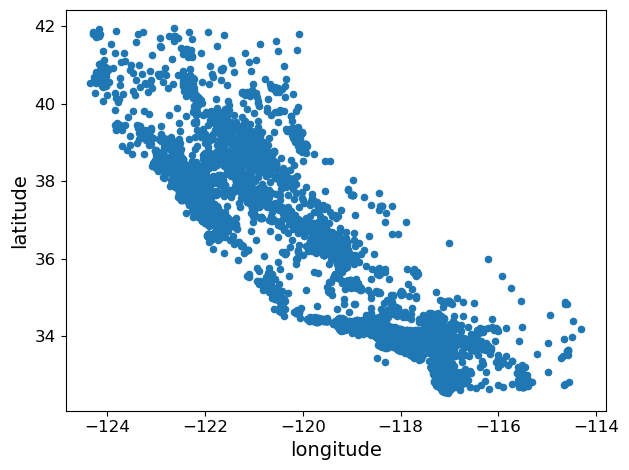

In [18]:
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig("bad_visualization_plot")

housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
save_fig("better_visualization_plot")


Saving figure housing_prices_scatterplot


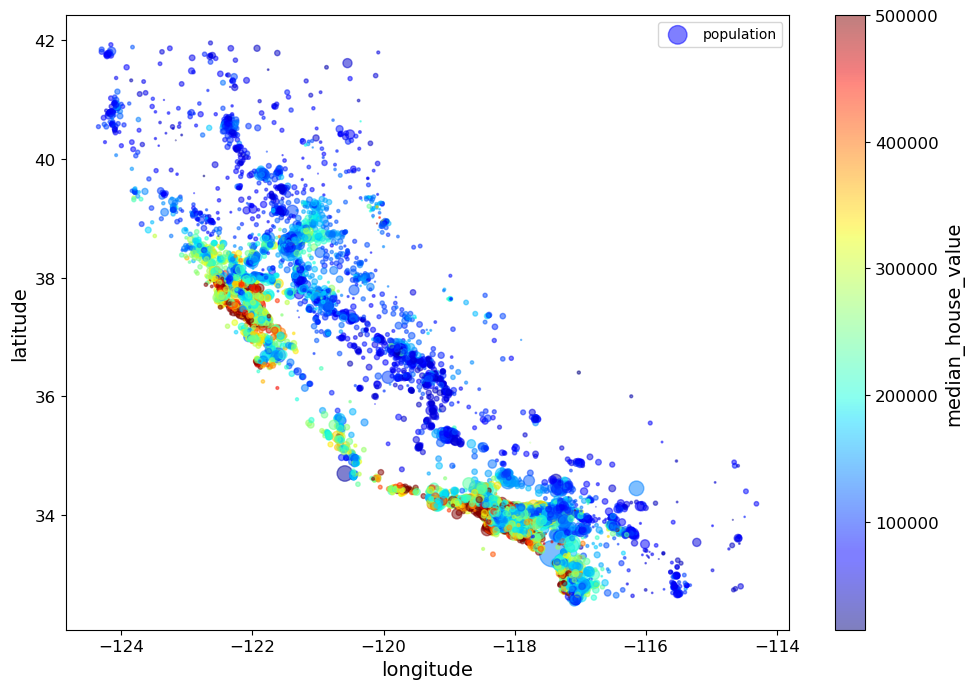

In [19]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.5,
    s=housing["population"] / 100,
    label="population",
    figsize=(10, 7),
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()
save_fig("housing_prices_scatterplot")

In [20]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


In [21]:
# Download the California image
images_path = os.path.join(PROJECT_ROOT_DIR, "images", PRJ_NAME)
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))

('.\\images\\house_price_prediction\\california.png',
 <http.client.HTTPMessage at 0x1ff1ebfbd70>)

Saving figure california_housing_prices_plot


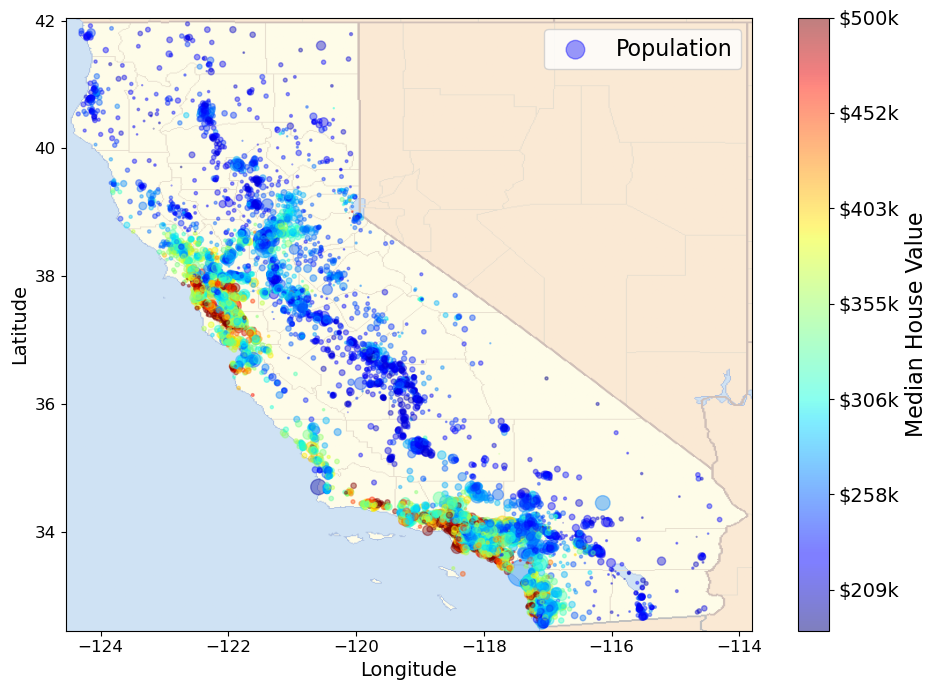

In [22]:
import matplotlib.image as mpimg

california_img = mpimg.imread(os.path.join(images_path, filename))
ax = housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    figsize=(10, 7),
    s=housing["population"] / 100,
    label="Population",
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=False,
    alpha=0.4,
)
plt.imshow(
    california_img,
    extent=[-124.55, -113.80, 32.45, 42.05],
    alpha=0.5,
    cmap=plt.get_cmap("jet"),
)
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values / prices.max())
cbar.ax.set_yticklabels(["$%dk" % (round(v / 1000)) for v in tick_values], fontsize=14)
cbar.set_label("Median House Value", fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()

#### Looking for Correlation


In [23]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7277
INLAND        5262
NEAR OCEAN    2124
NEAR BAY      1847
ISLAND           2
Name: count, dtype: int64

In [24]:
housing.groupby("ocean_proximity")["median_house_value"].mean().sort_values()

ocean_proximity
INLAND        125320.566515
<1H OCEAN     240830.511612
NEAR OCEAN    248359.495763
NEAR BAY      258740.476448
ISLAND        351100.000000
Name: median_house_value, dtype: float64

In [25]:
corr_matrix = housing.select_dtypes(include=["number"]).corr()

In [26]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

Saving figure housing_pariplot


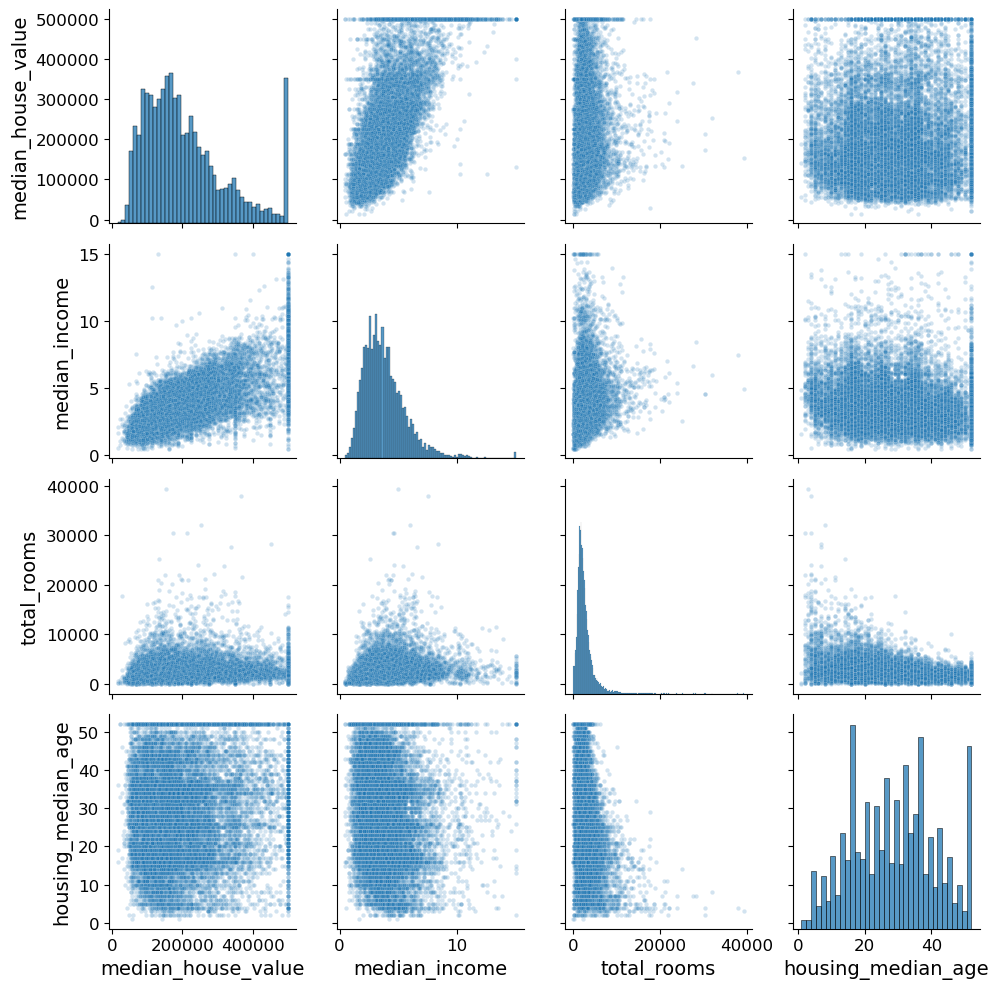

In [27]:
import seaborn as sns

attributes = [
    "median_house_value",
    "median_income",
    "total_rooms",
    "housing_median_age",
]

sns.pairplot(housing[attributes], plot_kws={"alpha": 0.2, "s": 10})
save_fig("housing_pariplot")

_Among all the features, median_income shows the strongest correlation with median_house_value, indicating a clear positive relationship between the income level of a neighborhood and housing prices. This makes sense because areas with higher median income typically have residents with greater purchasing power, which drives demand and increases property values. Therefore, median_income is one of the most informative predictors for estimating median house value in this dataset._


Saving figure income_vs_house_value_scatterplot


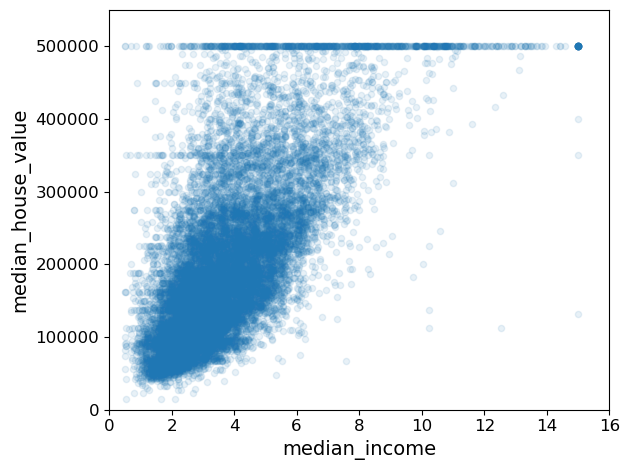

In [28]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)
plt.axis([0, 16, 0, 550000])
save_fig("income_vs_house_value_scatterplot")

#### Experimenting with Attribute Combinations


Creating new features by combining existing attributes helps the model capture more meaningful relationships in the data. Raw totals like total_rooms, total_bedrooms, or population do not fully describe housing conditions unless they are viewed relative to the number of households. Ratios such as rooms per household, bedrooms per room, and population per household provide better indicators of housing density, living space, and occupancy patterns. This process, known as feature engineering, can improve the predictive performance of machine learning models.


In [29]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

In [30]:
corr_matrix = housing.select_dtypes(include=["number"]).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

## Prepare the Data for Machine Learning Algorithms


In [31]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

#### Data Cleaning


In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=["number"])
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [33]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns)

#### Handling Text and Categorical Attributes


In [34]:
housing_cat = housing.select_dtypes(exclude=["number"])
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [35]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [36]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [37]:
housing_cat_1hot.toarray

<bound method _cs_matrix.toarray of <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>>

### Custom Transformers


In [38]:
# from sklearn.base import BaseEstimator, TransformerMixin

# class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
#     def __init__(self, add_bedrooms_per_room=True) -> None:
#         self.add_bedrooms_per_room = add_bedrooms_per_room

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):

#         # Get column indices.
#         col_names = (
#             "total_rooms",
#             "total_bedrooms",
#             "population",
#             "households",
#         )
#         rooms_ix, bedrooms_ix, population_ix, households_ix = [
#             housing.columns.get_loc(c) for c in col_names
#         ]

#         rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
#         population_per_household = X[:, population_ix] / X[:, households_ix]
#         if self.add_bedrooms_per_room:
#             bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
#             return np.c_[
#                 X, rooms_per_household, population_per_household, bedrooms_per_room
#             ]
#         else:
#             return np.c_[X, rooms_per_household, population_per_household]


# attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
# housing_extra_attribs = attr_adder.transform(housing.values)

# housing_extra_attribs = pd.DataFrame(
#     housing_extra_attribs,
#     columns=list(housing.columns)
#     + [
#         "rooms_per_household",
#         "population_per_household",
#     ],
#     index=housing.index,
# )
# housing_extra_attribs

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np


class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        # If X is a DataFrame, store column indices
        if hasattr(X, "columns"):
            self.rooms_ix = X.columns.get_loc("total_rooms")
            self.bedrooms_ix = X.columns.get_loc("total_bedrooms")
            self.population_ix = X.columns.get_loc("population")
            self.households_ix = X.columns.get_loc("households")
        else:
            # fallback if X is already a NumPy array
            self.rooms_ix = 3
            self.bedrooms_ix = 4
            self.population_ix = 5
            self.households_ix = 6

        return self

    def transform(self, X):
        X = np.asarray(X)

        rooms_per_household = X[:, self.rooms_ix] / X[:, self.households_ix]
        population_per_household = X[:, self.population_ix] / X[:, self.households_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, self.bedrooms_ix] / X[:, self.rooms_ix]
            return np.c_[
                X, rooms_per_household, population_per_household, bedrooms_per_room
            ]

        return np.c_[X, rooms_per_household, population_per_household]

### Transformation Piplines


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("attribs_adder", CombinedAttributesAdder()),
        ("std_scaler", StandardScaler()),
    ]
)

housing_num_tr = num_pipeline.fit_transform(housing_num)
housing_num_tr

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264, -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077, -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.33827252],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619,  0.32286937],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604, -0.45702273],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083, -0.12169672]], shape=(16512, 11))

In [40]:
# ColumnTransformer lets you apply different preprocessing
# steps to different columns of your dataset at the same time.
from sklearn.compose import ColumnTransformer

num_attribs = housing.select_dtypes(include=["number"]).columns
cat_attribs = housing.select_dtypes(exclude=["number"]).columns

preprocessing_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
    ]
)
housing_prepared = preprocessing_pipeline.fit_transform(housing)

housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 16))

In [41]:
print(type(housing_prepared))

<class 'numpy.ndarray'>


## Select and Train a Model


#### Training and Evaluating on the Training Set


In [42]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Let’s try it out on a few instances from the training set


In [ ]:
# let's try the full preprocessing pipeline on a few training instances

some_data = housing.iloc[:5]
some_labels = housing_labels[:5]
some_data_prepared = preprocessing_pipeline.transform(some_data)

print("Predictions : ", lin_reg.predict(some_data_prepared))
print("Labels : ", list(some_labels))

Predictions :  [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels :  [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [44]:
from sklearn.metrics import root_mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68627.87390018743

The model is underfitting: the prediction error (RMSE ≈ 68k) is large compared to the target value range (≈120k–265k). This suggests the model is too simple or the features are not informative enough. Possible improvements include using a more powerful model or engineering better features.


In [45]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [46]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

The absence of error is a strong sign that the model has overfit the training data. To evaluate the model's performance reliably without using the test set, we should use a portion of the training data for validation, typically by implementing K-fold cross-validation.


##### Better Evaluation using Cross-Validation


In [47]:
from sklearn.model_selection import cross_val_score

# For DecisionTreeRegressor
tree_scores = cross_val_score(
    tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10
)
tree_rmse_scores = np.sqrt(-tree_scores)

# For LinearRegression
lin_scores = cross_val_score(
    lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10
)
lin_rmse_scores = np.sqrt(-lin_scores)

In [48]:
def display_scores(scores):
    print("Scores : ", scores)
    print("Mean : ", scores.mean())
    print("Standard Deviation : ", scores.std())


# For DecisionTreeRegressor
print("=====Scores for DecisionTreeRegressor=====")
display_scores(tree_rmse_scores)

# For LinearRegression
print("=====Score for LinearRegression=====")
display_scores(lin_rmse_scores)

=====Scores for DecisionTreeRegressor=====
Scores :  [73349.55376367 70414.10934749 68739.64628815 71828.97570521
 68644.14025387 79185.69084792 71229.11442587 73522.18347981
 67465.48747441 71545.08079853]
Mean :  71592.3982384931
Standard Deviation :  3160.8561852048824
=====Score for LinearRegression=====
Scores :  [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean :  69104.07998247063
Standard Deviation :  2880.3282098180675


In [49]:
# Trying  a different model since the above two was not reliable

from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

18650.698705770003

In [51]:
forest_scores = cross_val_score(
    forest_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10,
)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores :  [51559.63379638 48737.57100062 47210.51269766 51875.21247297
 47577.50470123 51863.27467888 52746.34645573 50065.1762751
 48664.66818196 54055.90894609]
Mean :  50435.58092066179
Standard Deviation :  2203.3381412764606


## Fine-Tune the Model


#### Grid Search


In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 20 (5×4) combinations of hyperparameters
    {"n_estimators": [10, 30, 50, 100, 200], "max_features": [2, 4, 6, 8]},
    # then try 16 (4×4) combinations with bootstrap set as False
    {
        "bootstrap": [False],
        "n_estimators": [30, 50, 100, 200],
        "max_features": [2, 3, 4, 6],
    },
]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (20+16)*5=180 rounds of training
grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [10, 30, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [30, 50, ...]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [53]:
grid_search.best_params_

{'bootstrap': False, 'max_features': 6, 'n_estimators': 200}

In [54]:
print(grid_search.best_estimator_)

RandomForestRegressor(bootstrap=False, max_features=6, n_estimators=200,
                      random_state=42)


In [55]:
cvres = grid_search.cv_results_

for mean_score, params in sorted(
    zip(cvres["mean_test_score"], cvres["params"]),
    key=lambda x: np.sqrt(-x[0]),
):
    print(np.sqrt(-mean_score), params)

48438.509235460886 {'bootstrap': False, 'max_features': 6, 'n_estimators': 200}
48631.487472942645 {'bootstrap': False, 'max_features': 4, 'n_estimators': 200}
48672.09378488607 {'bootstrap': False, 'max_features': 6, 'n_estimators': 100}
48712.39937676116 {'bootstrap': False, 'max_features': 4, 'n_estimators': 100}
48885.67241927339 {'bootstrap': False, 'max_features': 4, 'n_estimators': 50}
48994.94581373121 {'bootstrap': False, 'max_features': 6, 'n_estimators': 50}
49163.65248358536 {'bootstrap': False, 'max_features': 3, 'n_estimators': 200}
49186.59493765748 {'max_features': 8, 'n_estimators': 200}
49198.34340551627 {'max_features': 6, 'n_estimators': 200}
49230.85818515138 {'bootstrap': False, 'max_features': 4, 'n_estimators': 30}
49317.94404891604 {'max_features': 6, 'n_estimators': 100}
49339.806213071206 {'max_features': 8, 'n_estimators': 100}
49341.259143094845 {'bootstrap': False, 'max_features': 3, 'n_estimators': 100}
49427.8803701667 {'bootstrap': False, 'max_features'

In [56]:
# Now let's put the Fine Tuning to a pipeline including the preprocessing part

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline(
    [
        ("preprocess", preprocessing_pipeline),
        ("model", RandomForestRegressor(random_state=42)),
    ]
)

param_grid = [
    {
        # model params
        "model__n_estimators": [10, 30, 50, 100, 200],
        "model__max_features": [2, 4, 6, 8],
        # preprocessing params
        "preprocess__num__imputer__strategy": ["mean", "median"],
        "preprocess__num__attribs_adder__add_bedrooms_per_room": [True, False],
        "preprocess__num__std_scaler": [StandardScaler(), "passthrough"],
    },
    {
        # model params
        "model__bootstrap": [False],
        "model__n_estimators": [30, 50, 100, 200],
        "model__max_features": [2, 3, 4, 6],
        # preprocessing params
        "preprocess__num__imputer__strategy": ["mean", "median"],
        "preprocess__num__attribs_adder__add_bedrooms_per_room": [True, False],
        "preprocess__num__std_scaler": [StandardScaler(), "passthrough"],
    },
]


forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=os.cpu_count() - 1,
    error_score="raise",
)
# We now pass housing instead of housing_prepared,
# because preprocessing is inside the pipeline.
grid_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'model__max_features': [2, 4, ...], 'model__n_estimators': [10, 30, ...], 'preprocess__num__attri...__add_bedrooms_per_room': [True, False], 'preprocess__num__imputer__strategy': ['mean', 'median'], ...}, {'model__bootstrap': [False], 'model__max_features': [2, 3, ...], 'model__n_estimators': [30, 50, ...], 'preprocess__num__attri...__add_bedrooms_per_room': [True, False], ...}]"
,scoring,'neg_mean_squared_error'
,n_jobs,15
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


#### Randomized Search


In [57]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    # model params
    "model__n_estimators": randint(90, 300),
    "model__max_features": randint(1, 9),
    "model__bootstrap": [True, False],
    # preprocessing params
    "preprocess__num__imputer__strategy": ["mean", "median"],
    "preprocess__num__attribs_adder__add_bedrooms_per_room": [True, False],
    "preprocess__num__std_scaler": [StandardScaler(), "passthrough"],
}

random_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distributions,
    n_iter=80,  # number of random combinations to try
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=os.cpu_count() - 1,
    return_train_score=True,
)

random_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__bootstrap': [True, False], 'model__max_features': <scipy.stats....001FF1FC1B530>, 'model__n_estimators': <scipy.stats....001FF1FBB0C20>, 'preprocess__num__attri...__add_bedrooms_per_room': [True, False], ...}"
,n_iter,80
,scoring,'neg_mean_squared_error'
,n_jobs,15
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [58]:
import numpy as np

grid_rmse = np.sqrt(-grid_search.best_score_)
rand_rmse = np.sqrt(-random_search.best_score_)

print("GridSearch RMSE:", grid_rmse)
print("RandomSearch RMSE:", rand_rmse)

GridSearch RMSE: 48067.051571593736
RandomSearch RMSE: 47965.07620441979


In [59]:
print("Grid best params:")
print(grid_search.best_params_)

print("\nRandom best params:")
print(random_search.best_params_)

Grid best params:
{'model__bootstrap': False, 'model__max_features': 6, 'model__n_estimators': 200, 'preprocess__num__attribs_adder__add_bedrooms_per_room': False, 'preprocess__num__imputer__strategy': 'median', 'preprocess__num__std_scaler': 'passthrough'}

Random best params:
{'model__bootstrap': False, 'model__max_features': 5, 'model__n_estimators': 258, 'preprocess__num__attribs_adder__add_bedrooms_per_room': False, 'preprocess__num__imputer__strategy': 'mean', 'preprocess__num__std_scaler': 'passthrough'}


In [60]:
best_pipeline = random_search.best_estimator_
best_model = best_pipeline.named_steps["model"]
feature_importances = best_model.feature_importances_
feature_importances

array([9.25804711e-02, 8.83484754e-02, 4.23566660e-02, 2.13963139e-02,
       1.90139054e-02, 2.05858863e-02, 1.81614081e-02, 3.30989031e-01,
       8.91298012e-02, 1.06124877e-01, 1.61851127e-02, 1.43482552e-01,
       9.36366023e-05, 5.14376207e-03, 6.40810194e-03])

In [61]:
best_preprocess = best_pipeline.named_steps["preprocess"]
cat_encoder = best_preprocess.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])

extra_attribs = ["rooms_per_hhold", "pop_per_hhold"]  # from the CombinedAttributesAdder

if random_search.best_params_["preprocess__num__attribs_adder__add_bedrooms_per_room"]:
    extra_attribs.append("bedrooms_per_room")

attributes = list(num_attribs) + extra_attribs + cat_one_hot_attribs

for score, name in sorted(zip(feature_importances, attributes), reverse=True):
    print(f"{name:20s} {score:.4f}")

median_income        0.3310
INLAND               0.1435
pop_per_hhold        0.1061
longitude            0.0926
rooms_per_hhold      0.0891
latitude             0.0883
housing_median_age   0.0424
total_rooms          0.0214
population           0.0206
total_bedrooms       0.0190
households           0.0182
<1H OCEAN            0.0162
NEAR OCEAN           0.0064
NEAR BAY             0.0051
ISLAND               0.0001


In [62]:
final_model = random_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print("Final RMSE:", final_rmse)

c:\Users\USER\.conda\envs\housing_ml-env\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Final RMSE: 45755.08515423438


In [ ]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(
    stats.t.interval(
        confidence,
        len(squared_errors) - 1,
        loc=squared_errors.mean(),
        scale=stats.sem(squared_errors),
    )
)

array([43780.22265837, 47648.1661654 ])

In [76]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np


class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        # # If X is a DataFrame, store column indices
        # if hasattr(X, "columns"):
        #     self.rooms_ix = X.columns.get_loc("total_rooms")
        #     self.bedrooms_ix = X.columns.get_loc("total_bedrooms")
        #     self.population_ix = X.columns.get_loc("population")
        #     self.households_ix = X.columns.get_loc("households")
        # else:
            # fallback if X is already a NumPy array
        self.rooms_ix = 3
        self.bedrooms_ix = 4
        self.population_ix = 5
        self.households_ix = 6

        return self

    def transform(self, X):
        X = np.asarray(X)

        rooms_per_household = X[:, self.rooms_ix] / X[:, self.households_ix]
        population_per_household = X[:, self.population_ix] / X[:, self.households_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, self.bedrooms_ix] / X[:, self.rooms_ix]
            return np.c_[
                X, rooms_per_household, population_per_household, bedrooms_per_room
            ]

        return np.c_[X, rooms_per_household, population_per_household]


import joblib

final_model = joblib.load("housing_price_pipeline.pkl")
X = housing.drop(columns=["median_house_value"])
y = housing.median_house_value
# final_model.fit(X, y)
X, y


(       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
 0        -122.23     37.88                41.0        880.0           129.0   
 1        -122.22     37.86                21.0       7099.0          1106.0   
 2        -122.24     37.85                52.0       1467.0           190.0   
 3        -122.25     37.85                52.0       1274.0           235.0   
 4        -122.25     37.85                52.0       1627.0           280.0   
 ...          ...       ...                 ...          ...             ...   
 20635    -121.09     39.48                25.0       1665.0           374.0   
 20636    -121.21     39.49                18.0        697.0           150.0   
 20637    -121.22     39.43                17.0       2254.0           485.0   
 20638    -121.32     39.43                18.0       1860.0           409.0   
 20639    -121.24     39.37                16.0       2785.0           616.0   
 
        population  households  median

In [77]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(final_model)

In [78]:
import pandas as pd

new_data = pd.DataFrame(
    [
        {
            "longitude": -118.29,
            "latitude": 34.05,
            "housing_median_age": 25,
            "total_rooms": 3000,
            "total_bedrooms": 500,
            "population": 1500,
            "households": 450,
            "median_income": 5.0,
            "ocean_proximity": "INLAND",
        },
        {
            "longitude": -121.89,
            "latitude": 37.33,
            "housing_median_age": 18,
            "total_rooms": 1500,
            "total_bedrooms": 300,
            "population": 900,
            "households": 280,
            "median_income": 6.2,
            "ocean_proximity": "NEAR OCEAN",
        },
    ]
)

final_model.predict(new_data)

c:\Users\USER\.conda\envs\housing_ml-env\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


array([249158.15116279, 284808.54651163])

In [ ]:
# import joblib

# joblib.dump(final_model, "housing_price_pipeline.pkl")

array([249158.15116279, 284808.54651163])

['housing_price_pipeline.pkl']